# 01 Data inspection: DHRD Singapore

Inspects the Delivery Hero Recommendation Dataset (Singapore) to check that it supports the
proposed approaches: size, missing values, sparsity, repeat behaviour, item attributes and the
delivery-distance constraint. Run `python scripts/download_data.py` first.

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from foodrec import config
from foodrec.data import load_order_lines, load_orders, load_vendors, load_products, temporal_split
from foodrec.geo import haversine_km
pd.set_option('display.width', 160, 'display.max_columns', 20)
FIG = config.ROOT / 'docs' / 'figures'

## 1. Raw tables

In [2]:
lines, vendors, products = load_order_lines(), load_vendors(), load_products()
orders = load_orders()
for name, df in [('order lines', lines), ('orders', orders), ('vendors', vendors), ('products', products)]:
    print(f'{name:<12} {df.shape}')
lines.head(8)

order lines  (3431870, 11)
orders       (1709414, 10)
vendors      (7411, 6)
products     (1066840, 4)


,customer_id,geohash,order_id,vendor_id,product_id,day_of_week,order_time,order_day,latitude,longitude,hour
0,f374c8c54c,w21zt,1,21830106,f245bdf79350,4,19:03:03,61,1.340332,103.952637,19
1,f374c8c54c,w21zt,1,21830106,146127be77d4,4,19:03:03,61,1.340332,103.952637,19
2,f374c8c54c,w21zt,1,21830106,6c108c0fb2b9,4,19:03:03,61,1.340332,103.952637,19
3,f374c8c54c,w21zt,1,21830106,da422c7836e1,4,19:03:03,61,1.340332,103.952637,19
4,f374c8c54c,w21zt,1,21830106,01110c80a0fa,4,19:03:03,61,1.340332,103.952637,19
5,f374c8c54c,w21zt,1,21830106,5289a6f50a7b,4,19:03:03,61,1.340332,103.952637,19
6,f374c8c54c,w21zt,1,21830106,64a268be5f2e,4,19:03:03,61,1.340332,103.952637,19
7,f374c8c54c,w21zt,1,21830106,adf53ab3befe,4,19:03:03,61,1.340332,103.952637,19


In [3]:
vendors.head(5)

,vendor_id,chain_id,geohash,primary_cuisine,latitude,longitude
0,b160c319,d2786168,w21z6,mexican,1.296387,103.820801
1,9c8f010e,d2786168,w21ze,mexican,1.340332,103.864746
2,03eb25e1,5055ab25,w21ze,bak kut teh,1.340332,103.864746
3,3613129a,8984acb6,w23b1,italian,1.428223,103.776855
4,0946c9e5,1e3a2913,w21z4,bak kut teh,1.252441,103.820801


In [4]:
products.head(5)

,vendor_id,product_id,name,unit_price
0,15bbf316,59099e089514,Meat & Seafood Combo 海鲜套餐,0.0036
1,e7b24dc0,52e1017fdbd9,Sausage Egg McMuffin® Meal,0.0024
2,e7b24dc0,fcb7110cd932,Scrambled Egg Burger w Chicken Meal,0.0024
3,7112a20b,d3e7708c2bc9,Maguro Sushi,0.0012
4,6137ef21,bf0d5ac0e03c,Family Meal - Prosp Chic TwLEVMx2 + ChBurgerHM,0.0100


## 2. Size, missing values and sparsity

In [5]:
n_cust, n_vend = orders.customer_id.nunique(), orders.vendor_id.nunique()
pairs = orders.groupby(['customer_id', 'vendor_id']).size()
summary = pd.Series({
    'order lines (products)': len(lines),
    'orders': len(orders),
    'customers': n_cust,
    'vendors with orders': n_vend,
    'vendors in catalogue': len(vendors),
    'products in catalogue': len(products),
    'products ordered': lines.product_id.nunique(),
    'chains': vendors.chain_id.str.startswith('solo_').eq(False).pipe(lambda s: vendors.chain_id[s].nunique()),
    'cuisines': vendors.primary_cuisine.nunique(),
    'customer geohash cells': orders.geohash.nunique(),
    'vendor geohash cells': vendors.geohash.nunique(),
    'days covered': orders.order_day.max() + 1,
    'customer-vendor pairs': len(pairs),
    'matrix density (%)': 100 * len(pairs) / (n_cust * n_vend),
})
summary.map(lambda x: f'{x:,.0f}' if x >= 1 else f'{x:.4f}').to_frame('value')

,value
order lines (products),"3,431,870"
orders,"1,709,414"
customers,"476,150"
vendors with orders,"7,203"
vendors in catalogue,"7,411"
products in catalogue,"1,066,840"
products ordered,"242,552"
chains,"1,854"
cuisines,78
customer geohash cells,45


In [6]:
print('missing values'); print(pd.concat({'orders': lines.isna().sum(), 'vendors': vendors.isna().sum(), 'products': products.isna().sum()}, axis=1).fillna('-'))
print('\nraw vendors without chain_id: 1,499 (filled as solo_<vendor_id>)')
print('products with price 0:', (products.unit_price == 0).mean().round(3))

missing values
                orders vendors products
customer_id        0.0       -        -
geohash            0.0     0.0        -
order_id           0.0       -        -
vendor_id          0.0     0.0      0.0
product_id         0.0       -      0.0
day_of_week        0.0       -        -
order_time         0.0       -        -
order_day          0.0       -        -
latitude           0.0     0.0        -
longitude          0.0     0.0        -
hour               0.0       -        -
chain_id             -     0.0        -
primary_cuisine      -     0.0        -
name                 -       -      0.0
unit_price           -       -      0.0

raw vendors without chain_id: 1,499 (filled as solo_<vendor_id>)
products with price 0: 0.276


## 3. Customer activity and repeat ordering

count    476150.00
mean          3.59
std           4.82
min           1.00
25%           1.00
50%           2.00
75%           4.00
max         296.00
dtype: float64
share with 1 order: 41.5%   >=5 orders: 22.1%   >=10 orders: 36561 customers


repeat share (non-first orders placed at an already-used vendor): 34.3%


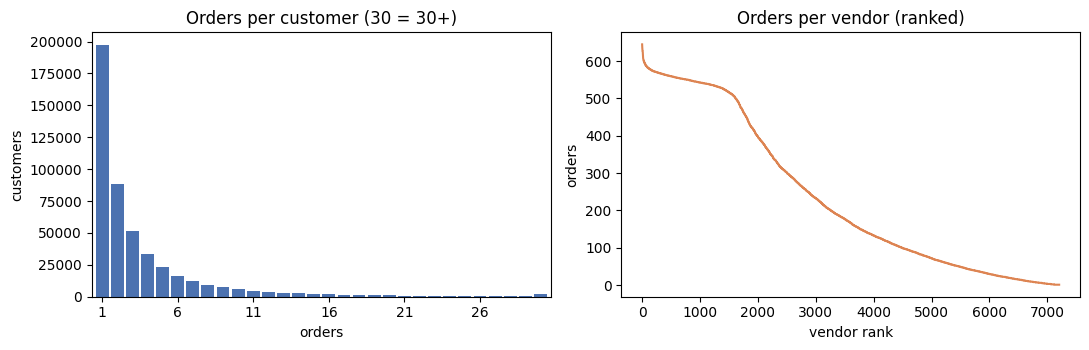

In [7]:
opc = orders.groupby('customer_id').size()
print(opc.describe().round(2))
print('share with 1 order: %.1f%%   >=5 orders: %.1f%%   >=10 orders: %d customers' % (100*(opc==1).mean(), 100*(opc>=5).mean(), (opc>=10).sum()))
o = orders.sort_values(['customer_id', 'order_day', 'order_time'])
repeat = o.duplicated(['customer_id', 'vendor_id'])[o.groupby('customer_id').cumcount() > 0].mean()
print('repeat share (non-first orders placed at an already-used vendor): %.1f%%' % (100*repeat))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
opc.clip(upper=30).value_counts().sort_index().plot.bar(ax=ax[0], color='#4C72B0', width=0.85)
ax[0].set(title='Orders per customer (30 = 30+)', xlabel='orders', ylabel='customers')
ax[0].set_xticks(range(0, 30, 5)); ax[0].set_xticklabels(range(1, 31, 5), rotation=0)
opv = orders.groupby('vendor_id').size().sort_values(ascending=False).values
ax[1].plot(np.arange(1, len(opv)+1), opv, color='#DD8452')
ax[1].set(title='Orders per vendor (ranked)', xlabel='vendor rank', ylabel='orders')
fig.tight_layout(); fig.savefig(FIG / 'activity.png', dpi=160)

## 4. Item attributes: cuisine and time of day

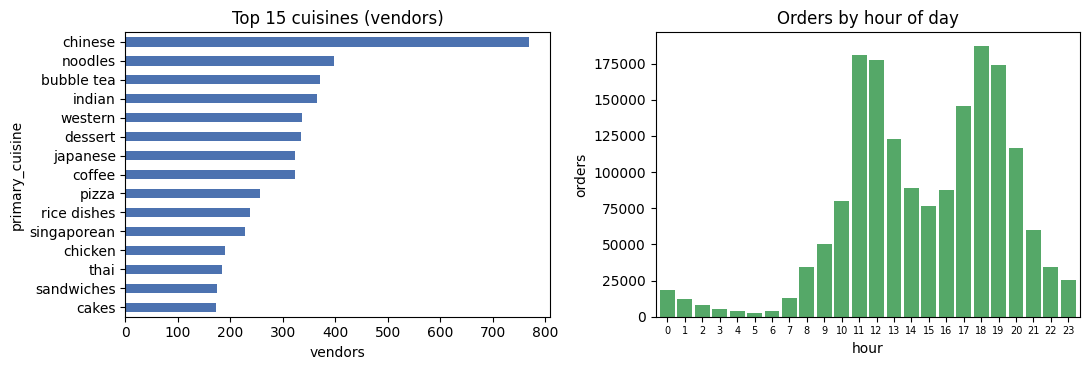

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
vendors.primary_cuisine.value_counts().head(15)[::-1].plot.barh(ax=ax[0], color='#4C72B0')
ax[0].set(title='Top 15 cuisines (vendors)', xlabel='vendors')
orders.hour.value_counts().sort_index().plot.bar(ax=ax[1], color='#55A868', width=0.85)
ax[1].set(title='Orders by hour of day', xlabel='hour', ylabel='orders'); ax[1].tick_params(axis='x', rotation=0, labelsize=7)
fig.tight_layout(); fig.savefig(FIG / 'cuisine_hour.png', dpi=160)

## 5. Delivery distance (sets the feasibility constraint)

Locations are 5-character geohash cells (~4.9 km); distance is measured between cell centres.

In [9]:
m = orders.merge(vendors[['vendor_id', 'latitude', 'longitude']], on='vendor_id', suffixes=('', '_v'))
d = haversine_km(m.latitude, m.longitude, m.latitude_v, m.longitude_v)
print(pd.Series(d).describe(percentiles=[.5, .75, .9, .95, .99]).round(2))
print('orders within %.0f km: %.2f%%' % (config.MAX_DELIVERY_KM, 100 * (d <= config.MAX_DELIVERY_KM).mean()))

count    1709414.00
mean           1.73
std            2.76
min            0.00
50%            0.00
75%            4.89
90%            4.89
95%            4.89
99%           10.92
max           29.72
dtype: float64
orders within 7 km: 98.74%


## 6. Temporal split used for evaluation

In [10]:
rows = []
for stage in ('valid', 'test'):
    h, t = temporal_split(orders, stage)
    warm = t.customer_id.isin(h.customer_id)
    rows.append({'stage': stage, 'history days': f'0-{h.order_day.max()}', 'target days': f'{t.order_day.min()}-{t.order_day.max()}',
                 'history orders': len(h), 'target orders': len(t), 'target customers': t.customer_id.nunique(),
                 'warm target customers (%)': round(100 * t.loc[warm, 'customer_id'].nunique() / t.customer_id.nunique(), 1)})
pd.DataFrame(rows)

,stage,history days,target days,history orders,target orders,target customers,warm target customers (%)
0,valid,0-61,62-68,1410689,153289,109842,80.4
1,test,0-68,69-75,1563978,145436,104890,81.6


## 7. Sample records (saved for the proposal)

In [11]:
sample = (lines.merge(vendors[['vendor_id', 'primary_cuisine']], on='vendor_id')
               .merge(products[['product_id', 'name', 'unit_price']], on='product_id')
               .sample(8, random_state=config.RANDOM_SEED)
               [['order_id', 'customer_id', 'geohash', 'vendor_id', 'primary_cuisine', 'product_id', 'name', 'unit_price', 'day_of_week', 'order_time', 'order_day']])
sample.to_csv(config.ROOT / 'docs' / 'samples' / 'orders_sample.csv', index=False)
vendors.head(5).to_csv(config.ROOT / 'docs' / 'samples' / 'vendors_sample.csv', index=False)
products.head(5).to_csv(config.ROOT / 'docs' / 'samples' / 'products_sample.csv', index=False)
sample

,order_id,customer_id,geohash,vendor_id,primary_cuisine,product_id,name,unit_price,day_of_week,order_time,order_day
2053081,1188376,54dc6d3cbf,w21z6,2ee5659d,chinese,7a3bd9266b83,1022 Marmite Chicken Bento Set 妈蜜鸡丁套餐,0.0048,6,18:13:26,35
1180195,673460,f68655bae9,w21zb,f49aea1a,japanese,120b8e43ac63,3.Salmon + Pork Katsu Bento 三文鱼+炸猪排饭盒,0.0028,5,16:27:36,62
281725,160126,3df0afd086,w21zu,49de578b,asian,69c47827dbdd,Vegetarian Bee Hoon,0.0048,3,08:48:05,4
2981031,1743166,969abe0e1d,w21zu,fbbb6785,burgers,e270cc3013bb,FISH’N CRISP CROISSAN'WICH® Meal,0.0028,1,09:29:28,23
3279699,1913308,2bdbc42d2c,w23bh,fc64fe17,chicken rice,2b2955250ae8,Roasted Chicken Rice with Beverage 烧鸡饭和水,0.0028,6,16:44:32,49
1888464,1089155,7f089e7e3f,w21ze,ddcf22f1,chicken rice,199589d9ae62,Signature White Chicken for 1 Pax,0.0024,3,12:31:58,74
2384584,1387829,c179bdbc9e,w21zt,5aa428a9,chinese,546b74422191,Fried Chinese Cabbage & Fungus with Garlic 木耳大白菜,0.0032,5,13:07:46,55
425631,242402,d7e2721d7b,w21zg,85443216,indian,0ebd485a06ce,B02. Briyani Chicken,0.0044,0,11:43:43,64
